In [44]:
import pandas as pd
import numpy as np
import polars as pl
import duckdb

In [45]:
data=pd.read_csv('2027Scheduler.csv')
#data=pd.read_excel('2026Scheduler.xlsx',sheet_name='ConductCounter')
data.head()

,Index,DateStart,DateEnd,DateSet,Course,Center,Teachers
0,Mandala1,2027/01/01,2027/01/04,1-01-2027 - 4-01-2027,3D,Mandala,U Aung Kyaw Nyan Wai - Daw Lay Sint
1,Mandala2,2027/01/08,2027/01/19,8-1-2027 - 19-1-2027,10D,Mandala,U Aung Kyaw Nyan Wai - Daw Khin Myint May
2,Mandala3,2027/02/02,2027/02/17,2-2-2027 - 17-2-2027,GC,Mandala,U Aung Kyaw Nyan Wai - Daw Hla Myint
3,Mandala4,2027/02/20,2027/03/23,20-2-2027 - 23-3-2027,30D,Mandala,U San Win Daw Tin Tin Ye
4,Mandala5,2027/04/09,2027/04/20,9-4-2027 - 20-4-2027,10D,Mandala,U Tun Tun Khaing - Daw Lay Sint


In [46]:
# List of CourseType opened in 2025
data['Course'].unique()

<ArrowStringArray>
['3D', '10D', 'GC', '30D', 'S10D', 'STP', 'TeenGirls', 'TeenBoys', '20D',
 '45D']
Length: 10, dtype: str

In [47]:
dataGB=data.groupby(['Center','Course'])['Course'].count()
#print(data.groupby(['Center','Course'])['Course'].count())
print(dataGB)

Center  Course   
Canda   10D           4
        TeenGirls     1
Joti    10D          16
        3D            3
        GC            1
                     ..
Sangam  10D           5
        STP           1
Shwe    10D           5
        3D            2
        STP           1
Name: Course, Length: 62, dtype: int64


In [48]:
# Create Pivot Table

# data cleaning removing 1d_2d short courses
df=data[~data['Course'].str.contains('sc')] # exclude 1D/2D

# Transpose Course Count Col to Pivot table
pivot_table = pd.pivot_table(df, index='Center', columns='Course', aggfunc='size', fill_value=0)

# add sum col in pivot table
pivot_table['Sum'] = pivot_table.sum(axis=1)

# save pivot_table to csv
pivot_table.to_csv('Courses2027PivotSummary.csv')

# Display the pivot table
print('2027 Vipassana Courses in Myanmar:')
print(' excluding 1day/2day courses')
print()
print(pivot_table)

2027 Vipassana Courses in Myanmar:
 excluding 1day/2day courses

Course       10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                      
Canda          4    0    0   0    0   0     0    0         0          1    5
Joti          16    0    0   3    0   1     0    2         1          1   24
Labha          6    0    0   0    0   0     0    1         0          0    7
Magga         11    0    0   0    0   0     0    0         0          0   11
MahaPabatta   10    0    0   0    0   0     0    1         0          0   11
Mahima1        7    0    0   0    0   0     0    1         0          1    9
Mahima2       12    2    0   0    0   0     1    1         0          0   16
Makuta         8    0    0   0    0   0     1    1         0          0   10
Mandala       11    0    1   2    0   1     1    1         0          0   17
Mani           5    0    0   1    0   0     0    1         0          1    8
Manohara   

In [87]:
# Long Course Centres

df = pd.DataFrame(data)

required_courses = {'20D', '30D', 'S10D'}

# Group by Centre and check if all required courses are present
filtered_centres = df.groupby('Center')['Course'].apply(lambda x: required_courses.issubset(set(x)))

# Get the Centres that meet the condition
valid_centres = filtered_centres[filtered_centres].index

# Filter the original DataFrame to include only the valid Centres
filtered_data = df[df['Center'].isin(valid_centres)]

# Get the unique Centres that meet the condition
unique_centres = filtered_centres[filtered_centres].index.tolist()

print('The Centres which operating Long Courses in 2027:')
print(unique_centres)


The Centres which operating Long Courses in 2027:
['Nidhi']


In [50]:
filteredSTP=data[data['Course']=='STP']
groupSTP=filteredSTP.groupby('Center')['Course'].count()
print('STP Course Count by Centre:')
groupSTP.sort_values(ascending=False)

STP Course Count by Centre:


Center
Joti           2
Nidhi          2
Manorama       1
Sangam         1
Pabbata        1
Nanadhaja      1
MittaYana      1
Mayuradipa     1
Manohara       1
Labha          1
Mani           1
Mandala        1
Makuta         1
Mahima2        1
Mahima1        1
MahaPabatta    1
Shwe           1
Name: Course, dtype: int64

In [51]:

import duckdb

# Create a DuckDB connection (in-memory database for this example)
#con = duckdb.connect()

con = duckdb.connect(database=':memory:')

# Execute the query
result = con.execute("""
    SELECT DateStart, Dateend, Course, Center
    FROM data
    WHERE Teachers LIKE '%U Kyaw Thu%'
    ORDER BY DateStart ASC;
""").fetchall()

# Print the results
#for row in result:
#    print(row)

print('ktkt courses')
result

ktkt courses


[('2027/03/11', '2027/03/22', '10D', 'Joti'),
 ('2027/04/09', '2027/04/20', '10D', 'MittaYana'),
 ('2027/06/01', '2027/07/02', '30D', 'Nidhi'),
 ('2027/09/18', '2027/09/29', '10D', 'MahaPabatta'),
 ('2027/10/13', '2027/10/24', '10D', 'Magga'),
 ('2027/11/24', '2027/12/05', '10D', 'Manorama')]

In [52]:
conn = duckdb.connect(database=':memory:')

conn.execute("CREATE TABLE people AS SELECT * FROM data")

KTKT_df = conn.execute("SELECT DateStart, DateEnd,Course,Center FROM data WHERE Teachers LIKE '%U Kyaw Thu%'").fetchdf()

print(KTKT_df)

    DateStart     DateEnd Course       Center
0  2027/04/09  2027/04/20    10D    MittaYana
1  2027/09/18  2027/09/29    10D  MahaPabatta
2  2027/11/24  2027/12/05    10D     Manorama
3  2027/10/13  2027/10/24    10D        Magga
4  2027/03/11  2027/03/22    10D         Joti
5  2027/06/01  2027/07/02    30D        Nidhi


In [53]:
# Date format set

data["DateStart"] = data["DateStart"].astype('datetime64[ns]')
data["DateEnd"] = data["DateEnd"].astype('datetime64[ns]')
data.head()

,Index,DateStart,DateEnd,DateSet,Course,Center,Teachers
0,Mandala1,2027-01-01,2027-01-04,1-01-2027 - 4-01-2027,3D,Mandala,U Aung Kyaw Nyan Wai - Daw Lay Sint
1,Mandala2,2027-01-08,2027-01-19,8-1-2027 - 19-1-2027,10D,Mandala,U Aung Kyaw Nyan Wai - Daw Khin Myint May
2,Mandala3,2027-02-02,2027-02-17,2-2-2027 - 17-2-2027,GC,Mandala,U Aung Kyaw Nyan Wai - Daw Hla Myint
3,Mandala4,2027-02-20,2027-03-23,20-2-2027 - 23-3-2027,30D,Mandala,U San Win Daw Tin Tin Ye
4,Mandala5,2027-04-09,2027-04-20,9-4-2027 - 20-4-2027,10D,Mandala,U Tun Tun Khaing - Daw Lay Sint


In [54]:
data["DateStart"] = data["DateStart"].astype('datetime64[ns]')
data["DateEnd"] = data["DateEnd"].astype('datetime64[ns]')
data.head()

,Index,DateStart,DateEnd,DateSet,Course,Center,Teachers
0,Mandala1,2027-01-01,2027-01-04,1-01-2027 - 4-01-2027,3D,Mandala,U Aung Kyaw Nyan Wai - Daw Lay Sint
1,Mandala2,2027-01-08,2027-01-19,8-1-2027 - 19-1-2027,10D,Mandala,U Aung Kyaw Nyan Wai - Daw Khin Myint May
2,Mandala3,2027-02-02,2027-02-17,2-2-2027 - 17-2-2027,GC,Mandala,U Aung Kyaw Nyan Wai - Daw Hla Myint
3,Mandala4,2027-02-20,2027-03-23,20-2-2027 - 23-3-2027,30D,Mandala,U San Win Daw Tin Tin Ye
4,Mandala5,2027-04-09,2027-04-20,9-4-2027 - 20-4-2027,10D,Mandala,U Tun Tun Khaing - Daw Lay Sint


In [55]:
# Month col add
data['Month'] = pd.DatetimeIndex(data['DateStart']).month


In [56]:
df=data[~data['Course'].str.contains('sc')] # exclude 1D/2D
#df.head()

In [57]:
import pandas as pd

# Convert DateStart and DateEnd to datetime format
df['DateStart'] = pd.to_datetime(df['DateStart'])
df['DateEnd'] = pd.to_datetime(df['DateEnd'])

# Find overlapping date ranges within the same Month
def find_overlapping_conduct(row, df):
    # Check for overlapping date ranges and the same Month
    overlapping = df[
        (df['Month'] == row['Month']) &  # Same Month
        (df['DateStart'] <= row['DateEnd']) &  # Overlapping start date
        (df['DateEnd'] >= row['DateStart']) &  # Overlapping end date
        (df.index != row.name)  # Exclude the current row
    ]
    return overlapping['Teachers'].tolist()

# Apply the function to find overlapping Conduct values
df['OverlappingConduct'] = df.apply(lambda row: find_overlapping_conduct(row, df), axis=1)

df[['Center','Month','DateStart','Course','Teachers']]

,Center,Month,DateStart,Course,Teachers
0,Mandala,1,2027-01-01,3D,U Aung Kyaw Nyan Wai - Daw Lay Sint
1,Mandala,1,2027-01-08,10D,U Aung Kyaw Nyan Wai - Daw Khin Myint May
2,Mandala,2,2027-02-02,GC,U Aung Kyaw Nyan Wai - Daw Hla Myint
3,Mandala,2,2027-02-20,30D,U San Win Daw Tin Tin Ye
4,Mandala,4,2027-04-09,10D,U Tun Tun Khaing - Daw Lay Sint
...,...,...,...,...,...
193,Nanadhaja,9,2027-09-18,10D,U Than Htay - Daw Kay Thi
194,Nanadhaja,10,2027-10-14,3D,U Tint Lwin - Daw Kay Thi
195,Nanadhaja,11,2027-11-12,10D,U Sein Win - Daw Win Win Myint
196,Nanadhaja,12,2027-12-18,STP,U Soe Min Aye - Daw Kay Thi


In [58]:
# Convert DateStart and DateEnd to datetime format
df['DateStart'] = pd.to_datetime(df['DateStart'])
df['DateEnd'] = pd.to_datetime(df['DateEnd'])

# Find overlapping date ranges
def find_overlapping_conduct(row, df):
    # Check for overlapping date ranges
    overlapping = df[
        (df['DateStart'] <= row['DateEnd']) & 
        (df['DateEnd'] >= row['DateStart']) & 
        (df.index != row.name)  # Exclude the current row
    ]
    return overlapping['Teachers'].tolist()

# Apply the function to find overlapping Conduct values
df['OverlappingConduct'] = df.apply(lambda row: find_overlapping_conduct(row, df), axis=1)

df[['Month','DateStart','Course','Center','Teachers']]

,Month,DateStart,Course,Center,Teachers
0,1,2027-01-01,3D,Mandala,U Aung Kyaw Nyan Wai - Daw Lay Sint
1,1,2027-01-08,10D,Mandala,U Aung Kyaw Nyan Wai - Daw Khin Myint May
2,2,2027-02-02,GC,Mandala,U Aung Kyaw Nyan Wai - Daw Hla Myint
3,2,2027-02-20,30D,Mandala,U San Win Daw Tin Tin Ye
4,4,2027-04-09,10D,Mandala,U Tun Tun Khaing - Daw Lay Sint
...,...,...,...,...,...
193,9,2027-09-18,10D,Nanadhaja,U Than Htay - Daw Kay Thi
194,10,2027-10-14,3D,Nanadhaja,U Tint Lwin - Daw Kay Thi
195,11,2027-11-12,10D,Nanadhaja,U Sein Win - Daw Win Win Myint
196,12,2027-12-18,STP,Nanadhaja,U Soe Min Aye - Daw Kay Thi


In [59]:
# Convert DateStart and DateEnd to datetime format
df['DateStart'] = pd.to_datetime(df['DateStart'])
df['DateEnd'] = pd.to_datetime(df['DateEnd'])

# Find overlapping date ranges within the same Centre
def find_overlapping_conduct(row, df):
    # Check for overlapping date ranges and the same Centre
    overlapping = df[
        (df['Center'] == row['Center']) &  # Same Centre
        (df['DateStart'] <= row['DateEnd']) &  # Overlapping start date
        (df['DateEnd'] >= row['DateStart']) &  # Overlapping end date
        (df.index != row.name)  # Exclude the current row
    ]
    return overlapping['Teachers'].tolist()

# Apply the function to find overlapping Conduct values
df['OverlappingConduct'] = df.apply(lambda row: find_overlapping_conduct(row, df), axis=1)
df

,Index,DateStart,DateEnd,DateSet,Course,Center,Teachers,Month,OverlappingConduct
0,Mandala1,2027-01-01,2027-01-04,1-01-2027 - 4-01-2027,3D,Mandala,U Aung Kyaw Nyan Wai - Daw Lay Sint,1,[]
1,Mandala2,2027-01-08,2027-01-19,8-1-2027 - 19-1-2027,10D,Mandala,U Aung Kyaw Nyan Wai - Daw Khin Myint May,1,[]
2,Mandala3,2027-02-02,2027-02-17,2-2-2027 - 17-2-2027,GC,Mandala,U Aung Kyaw Nyan Wai - Daw Hla Myint,2,[]
3,Mandala4,2027-02-20,2027-03-23,20-2-2027 - 23-3-2027,30D,Mandala,U San Win Daw Tin Tin Ye,2,[]
4,Mandala5,2027-04-09,2027-04-20,9-4-2027 - 20-4-2027,10D,Mandala,U Tun Tun Khaing - Daw Lay Sint,4,[]
...,...,...,...,...,...,...,...,...,...
193,Nanadha5,2027-09-18,2027-09-29,18-09-2027 - 29-09-2027,10D,Nanadhaja,U Than Htay - Daw Kay Thi,9,[]
194,Nanadha6,2027-10-14,2027-10-17,14-10-2027 - 17-10-2027,3D,Nanadhaja,U Tint Lwin - Daw Kay Thi,10,[]
195,Nanadha7,2027-11-12,2027-11-23,12-11-2027 - 23-11-2027,10D,Nanadhaja,U Sein Win - Daw Win Win Myint,11,[]
196,Nanadha8,2027-12-18,2027-12-26,18-12-2027 - 26-12-2027,STP,Nanadhaja,U Soe Min Aye - Daw Kay Thi,12,[]


In [60]:
# Create Pivot Table

# data cleaning removing 1d_2d short courses
df=data[~data['Course'].str.contains('sc')] # exclude 1D/2D

# Transpose Course Count Col to Pivot table
pivot_table = pd.pivot_table(df, index='Center', columns='Course', aggfunc='size', fill_value=0)

# add sum col in pivot table
pivot_table['Sum'] = pivot_table.sum(axis=1)

# save pivot_table to csv
pivot_table.to_csv('Courses2027PivotSummary.csv')

# Display the pivot table
print('2027 Vipassana Courses in Myanmar:')
print(' excluding 1day/2day courses')
print()
print(pivot_table)

2027 Vipassana Courses in Myanmar:
 excluding 1day/2day courses

Course       10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                      
Canda          4    0    0   0    0   0     0    0         0          1    5
Joti          16    0    0   3    0   1     0    2         1          1   24
Labha          6    0    0   0    0   0     0    1         0          0    7
Magga         11    0    0   0    0   0     0    0         0          0   11
MahaPabatta   10    0    0   0    0   0     0    1         0          0   11
Mahima1        7    0    0   0    0   0     0    1         0          1    9
Mahima2       12    2    0   0    0   0     1    1         0          0   16
Makuta         8    0    0   0    0   0     1    1         0          0   10
Mandala       11    0    1   2    0   1     1    1         0          0   17
Mani           5    0    0   1    0   0     0    1         0          1    8
Manohara   

In [61]:
df=data[~data['Course'].str.contains('sc')] # exclude 1D/2D
pivot_table = pd.pivot_table(df, index='Center', columns='Course', aggfunc='size', fill_value=0)
pivot_table['Sum'] = pivot_table.sum(axis=1)

# Filter rows where 'Sum' > 8
filtered_data = pivot_table[pivot_table['Sum'] > 8]
print('The Centers running Courses > 8 in the Year ')
print()
print(filtered_data)

The Centers running Courses > 8 in the Year 

Course       10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                      
Joti          16    0    0   3    0   1     0    2         1          1   24
Magga         11    0    0   0    0   0     0    0         0          0   11
MahaPabatta   10    0    0   0    0   0     0    1         0          0   11
Mahima1        7    0    0   0    0   0     0    1         0          1    9
Mahima2       12    2    0   0    0   0     1    1         0          0   16
Makuta         8    0    0   0    0   0     1    1         0          0   10
Mandala       11    0    1   2    0   1     1    1         0          0   17
Manohara       8    0    0   0    0   0     0    1         0          1   10
Manorama       6    0    0   1    0   0     0    1         1          1   10
Nidhi          7    1    2   0    2   0     1    2         0          0   15


In [62]:
# Filter rows where 'Sum' > 10 and < =24
fdf= pivot_table

filtered_data = fdf[(fdf['Sum'] > 10) & (fdf['Sum'] <= 24)]

print('The Centers running Courses > 10 and <= 24 in the Year ')
print()
print(filtered_data.Sum.sort_values(ascending=False))

The Centers running Courses > 10 and <= 24 in the Year 

Center
Joti           24
Mandala        17
Mahima2        16
Nidhi          15
Magga          11
MahaPabatta    11
Name: Sum, dtype: int64


In [63]:
filtered_data = fdf[(fdf['Sum'] >= 7) & (fdf['Sum'] < 10)]
print('The Centers running Courses >= 7 and < 10 in the Year ')
print('')
print(filtered_data)

The Centers running Courses >= 7 and < 10 in the Year 

Course      10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                     
Labha         6    0    0   0    0   0     0    1         0          0    7
Mahima1       7    0    0   0    0   0     0    1         0          1    9
Mani          5    0    0   1    0   0     0    1         0          1    8
Mayuradipa    6    0    0   0    0   0     0    1         0          0    7
MittaYana     6    0    0   0    0   0     0    1         0          0    7
Nanadhaja     6    0    0   1    0   0     0    1         0          0    8
Pabbata       7    0    0   0    0   0     0    1         0          0    8
Shwe          5    0    0   2    0   0     0    1         0          0    8


In [64]:
# Filter rows where 'Sum' < 7
filtered_data = pivot_table[pivot_table['Sum'] < 7]
print('The Centers running Courses < 7 in the Year ')
print()
print(filtered_data)

The Centers running Courses < 7 in the Year 

Course      10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                     
Canda         4    0    0   0    0   0     0    0         0          1    5
NC_Ahtaung    1    0    0   0    0   0     0    0         0          0    1
Sangam        5    0    0   0    0   0     0    1         0          0    6


In [65]:
# Filter rows where 'Sum' < 6
filtered_data = pivot_table[pivot_table['Sum'] < 6]
print('The Centers running Courses < 6 in the Year ')
print()
print(filtered_data)

The Centers running Courses < 6 in the Year 

Course      10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                     
Canda         4    0    0   0    0   0     0    0         0          1    5
NC_Ahtaung    1    0    0   0    0   0     0    0         0          0    1


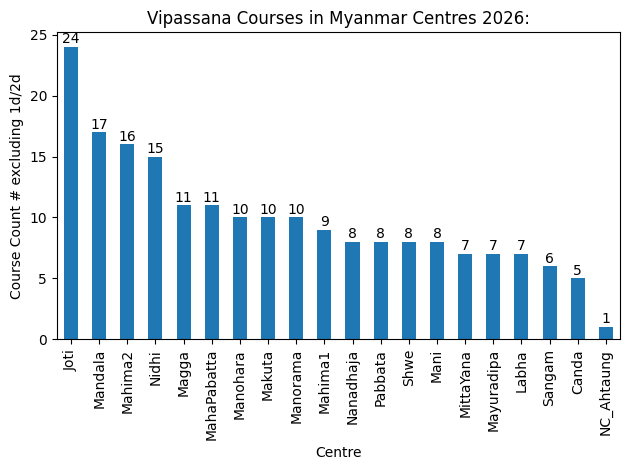

In [66]:
# bar plot in descending order
import matplotlib.pyplot as plt

grouped=pivot_table.Sum.sort_values(ascending=False)

ax=grouped.plot(kind='bar', title='Vipassana Courses in Myanmar Centres 2026:')

plt.xlabel('Centre')
plt.ylabel('Course Count # excluding 1d/2d')

# add label
for i, v in enumerate(grouped):
    ax.text(i,v + 0.05,str(v),ha= 'center',va='bottom')
plt.tight_layout()
plt.show()

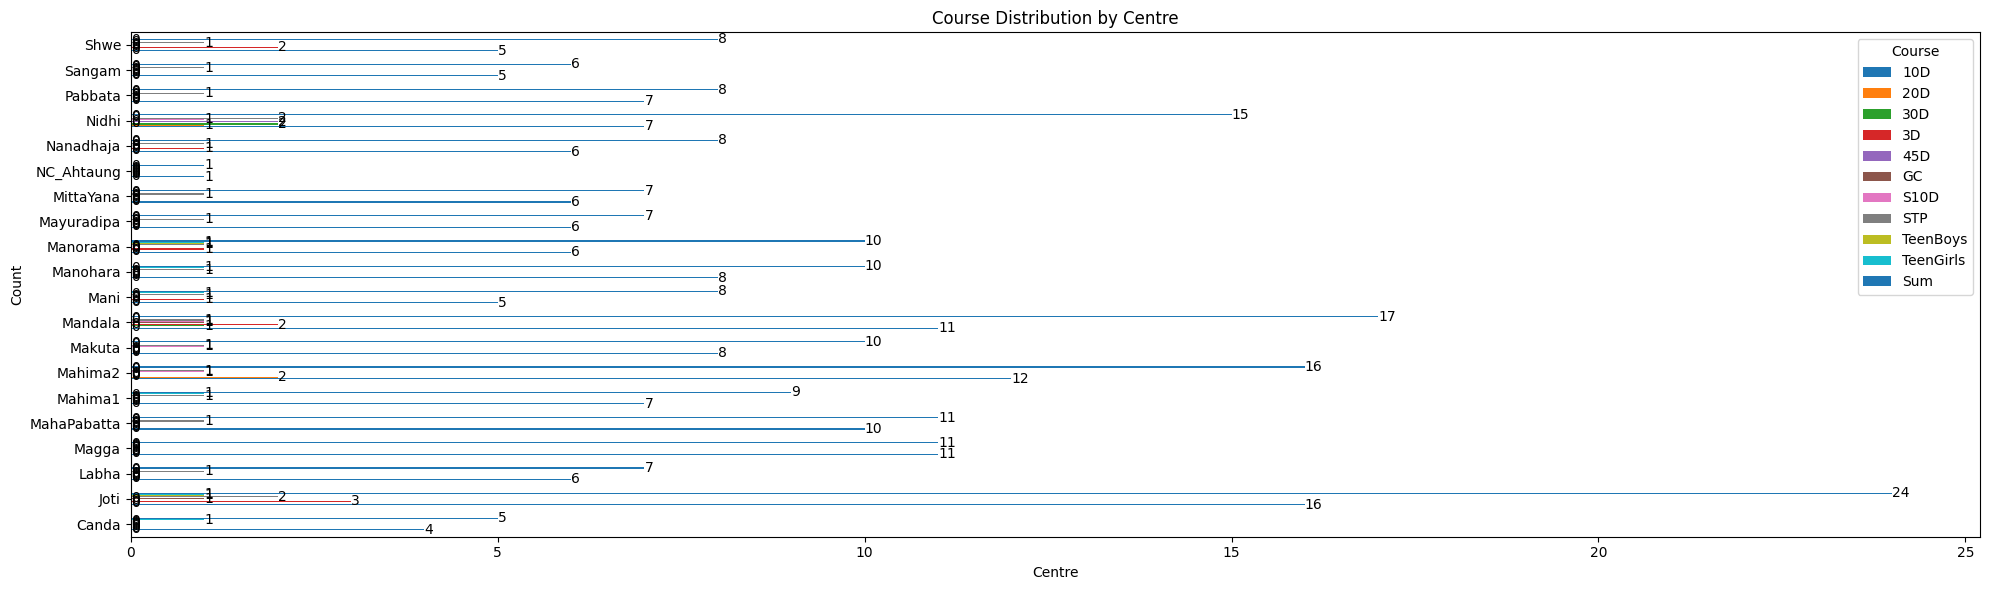

In [67]:
import pandas as pd
import matplotlib.pyplot as plt


# Plot the pivot table as a bar plot
pivot_table.plot(kind='barh', figsize=(20, 6))

# Add labels on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')

# Customize the plot
plt.title('Course Distribution by Centre')
plt.xlabel('Centre')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.legend(title='Course')
plt.tight_layout()

# Show the plot
plt.show()

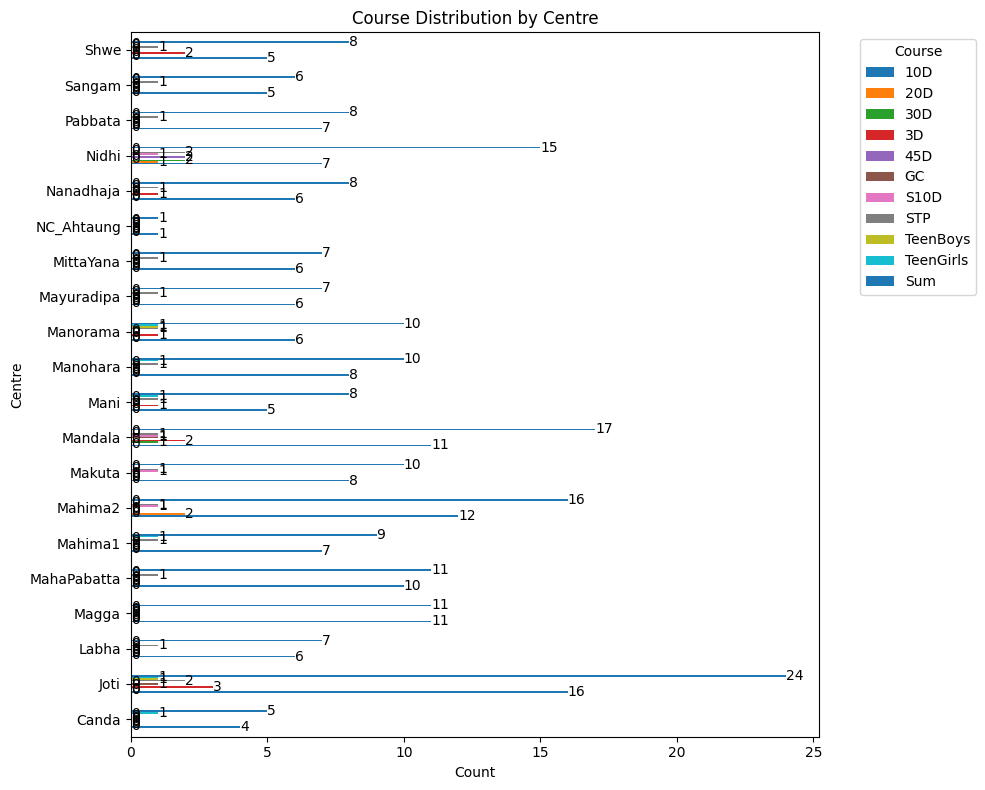

In [68]:
pivot_table.plot(kind='barh', figsize=(10, 8))

# Add labels on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')

# Customize the plot
plt.title('Course Distribution by Centre')
plt.xlabel('Count')
plt.ylabel('Centre')
plt.legend(title='Course', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()

# Show the plot
plt.show()

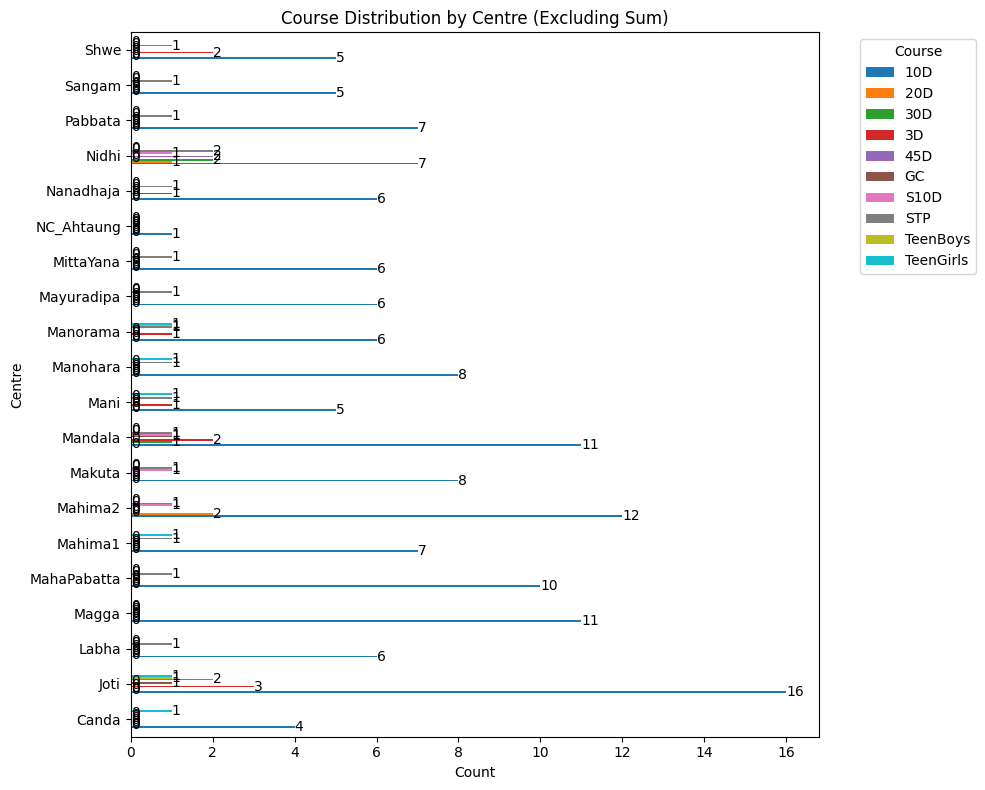

In [69]:
# Exclude the "Sum" column from the plot
pivot_table_without_sum = pivot_table.drop(columns='Sum')

# Plot the pivot table as a horizontal bar plot
pivot_table_without_sum.plot(kind='barh', figsize=(10, 8))

# Add labels on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, label_type='edge')

# Customize the plot
plt.title('Course Distribution by Centre (Excluding Sum)')
plt.xlabel('Count')
plt.ylabel('Centre')
plt.legend(title='Course', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()

In [70]:
# AT Filter

In [71]:


# date time
df['DateStart'] = pd.to_datetime(df['DateStart'])
df['DateEnd'] = pd.to_datetime(df['DateEnd'])

# specified date range
start_date = pd.to_datetime('2027-10-07')
end_date = pd.to_datetime('2027-11-05')

# Find result 

filtered_df = df[
    (df['DateEnd'] >= start_date) & 
    (df['DateStart'] <= end_date)
]

print('Conducting AT at the Specified Date Range:')
filtered_df[['Teachers','Center','Course','DateStart','DateEnd']]

Conducting AT at the Specified Date Range:


,Teachers,Center,Course,DateStart,DateEnd
12,"U Khin Maung Soe - Daw ,Nwe ,Nwe Aye",Mandala,10D,2027-10-07,2027-10-18
13,U Kyi Ohn - Daw Mya San,Mandala,10D,2027-10-25,2027-11-05
30,U Chandra Kumar - Daw Swe Swe Maw,Mani,10D,2027-11-04,2027-11-15
41,U Thein Htwe - Daw Mi Mi Myaing,MahaPabatta,STP,2027-10-23,2027-10-31
48,U Win Maung - Daw Win Win Myint,Shwe,3D,2027-10-13,2027-10-16
56,Dr Tin Mg Yin Daw Swe Swe Win,Labha,STP,2027-10-03,2027-10-11
64,U Aung Myat Cho - Daw Tin Tin Mya,Mayuradipa,STP,2027-10-23,2027-10-31
73,U Kyaw Mya - Daw Tin Tin Aye,Manorama,3D,2027-10-13,2027-10-16
84,U Tin Lu Win Daw Myint Myint Si,Manohara,10D,2027-10-20,2027-10-31
92,U Kyi Ohn - Daw Lay Sint,Pabbata,10D,2027-10-03,2027-10-14


In [72]:
KTKT_df = con.execute("SELECT Month,DateStart,Teachers,Course,Center FROM data WHERE Teachers LIKE '%U Win Myint%'").fetchdf()

# Display the result
#print(KTKT_df)
#KTKT_df.sort_values(by='Month', ascending= True)
print('     UWMyint Course in 2027:')
KTKT_df.sort_values(by='DateStart',ascending=True)

     UWMyint Course in 2027:


,Month,DateStart,Teachers,Course,Center
3,1,2027-01-22,U Win Myint - Daw Aye Myint,STP,Joti
5,4,2027-04-09,U Win Myint - Daw Nyo Nyo Win,10D,NC_Ahtaung
1,5,2027-05-23,U Win Myint - Daw Swe Swe Maw,10D,Mahima1
0,6,2027-06-14,U Win Myint - Daw Nyo Nyo Win,STP,Manorama
4,7,2027-07-22,U Win Myint - Daw Hla Myint,10D,Joti
2,10,2027-10-04,U Win Myint - Daw Nyo Nyo Win,10D,Mahima1


In [73]:
# Transpose Course Count Col
pivot_table2 = pd.pivot_table(df, index='Center', columns='Course', aggfunc='size', fill_value=0)

pivot_table2.to_csv('Courses2027Pivot.csv')
# Display the pivot table
print('2027 Vipassana Courses in Myanmar:')
print(' excluding 1day/2day courses')
print()
print(pivot_table2)

2027 Vipassana Courses in Myanmar:
 excluding 1day/2day courses

Course       10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls
Center                                                                 
Canda          4    0    0   0    0   0     0    0         0          1
Joti          16    0    0   3    0   1     0    2         1          1
Labha          6    0    0   0    0   0     0    1         0          0
Magga         11    0    0   0    0   0     0    0         0          0
MahaPabatta   10    0    0   0    0   0     0    1         0          0
Mahima1        7    0    0   0    0   0     0    1         0          1
Mahima2       12    2    0   0    0   0     1    1         0          0
Makuta         8    0    0   0    0   0     1    1         0          0
Mandala       11    0    1   2    0   1     1    1         0          0
Mani           5    0    0   1    0   0     0    1         0          1
Manohara       8    0    0   0    0   0     0    1         0          1

In [74]:


con = duckdb.connect(database=':memory:')

# Load DataFrame into DuckDB
con.execute("CREATE TABLE people AS SELECT * FROM data")

# Query to fetch names that include 'Ali'
result_df = con.execute("SELECT Month,DateStart,DateEnd,Course,Center FROM data WHERE Teachers LIKE '%U Kyaw Thu%'").fetchdf()

# Display the result
print('My Courses in 2027:')
print(result_df)

My Courses in 2027:
   Month  DateStart    DateEnd Course       Center
0      4 2027-04-09 2027-04-20    10D    MittaYana
1      9 2027-09-18 2027-09-29    10D  MahaPabatta
2     11 2027-11-24 2027-12-05    10D     Manorama
3     10 2027-10-13 2027-10-24    10D        Magga
4      3 2027-03-11 2027-03-22    10D         Joti
5      6 2027-06-01 2027-07-02    30D        Nidhi


In [75]:
con = duckdb.connect(database=':memory:')

# Load DataFrame into DuckDB
con.execute("CREATE TABLE people AS SELECT * FROM data")

# Query to fetch names that include 'Ali'
result_df = con.execute("SELECT Month,DateStart,Course,Teachers FROM data WHERE Center== 'Joti'").fetchdf()

# Display the result
print('Joti 2027 Courses:')
result_df

Joti 2027 Courses:


,Month,DateStart,Course,Teachers
0,1,2027-01-01,3D,U Hlaing - Daw Yin Hla
1,1,2027-01-08,10D,U Khin Maung Win - Daw Tin Tin Mya
2,1,2027-01-22,STP,U Win Myint - Daw Aye Myint
3,2,2027-02-02,GC,U Tin Maung - Dr Nyunt Nyunt Sein
4,2,2027-02-25,10D,U Hlaing - Daw Hla Hla Myint
5,3,2027-03-11,10D,U Kyaw Thu Daw Kyi Kyi Tun
6,3,2027-03-29,TeenBoys,U Aung Myat Cho U Tin Lu WIn
7,4,2027-04-09,10D,U Mg Mg Lwin - Daw Yema Maw Naing
8,4,2027-04-23,TeenGirls,Daw Mya San Daw Ohn Ye
9,5,2027-05-06,10D,U San Lwin Daw Tin Tin Naing


In [76]:
conn = duckdb.connect(database=':memory:')

# Select specific columns and filter rows
result_df = conn.execute("""
    SELECT DateStart, Course,Center, Teachers
    FROM data
    WHERE Center == 'Nidhi' and Month == 6
""").fetchdf()

# Display the filtered DataFrame
print(result_df)

   DateStart Course Center                     Teachers
0 2027-06-01    30D  Nidhi  U Kyaw Thu  Daw Kyi Kyi Tun


In [77]:
conn = duckdb.connect(database=':memory:')

# Select specific columns and filter rows
result_df = conn.execute("""
    SELECT DateStart, Month,Course,Center,Teachers
    FROM data
    WHERE Course == '30D' and Teachers LIKE '%U Kyaw Thu%'
""").fetchdf()

# Display the filtered DataFrame
result_df.sort_values(by='Month', ascending= True)

,DateStart,Month,Course,Center,Teachers
0,2027-06-01,6,30D,Nidhi,U Kyaw Thu Daw Kyi Kyi Tun


In [78]:
conn = duckdb.connect(database=':memory:')

# Select specific columns and filter rows
result_df = conn.execute("""
    SELECT DateStart, Course,Center, Teachers
    FROM data
    WHERE Course == 'STP' and Teachers LIKE '%U Kyaw Thu%'
""").fetchdf()

# Display the filtered DataFrame
print(result_df)

Empty DataFrame
Columns: [DateStart, Course, Center, Teachers]
Index: []


In [79]:
conn = duckdb.connect(database=':memory:')

# Select specific columns and filter rows
result_df = conn.execute("""
    SELECT DateStart, Course,Center, Teachers
    FROM data
    WHERE Month >= 4 and Teachers LIKE '%U Thein Htwe%'
""").fetchdf()

# Display the filtered DataFrame
print(result_df)

   DateStart Course       Center                           Teachers
0 2027-10-23    STP  MahaPabatta    U Thein Htwe - Daw Mi Mi Myaing
1 2027-05-19    10D        Labha        U Thein Htwe - Daw Than Aye
2 2027-04-12    10D      Pabbata       U Thein Htwe - Daw Soe Phint
3 2027-05-06    10D      Pabbata        U Thein Htwe - Daw Than Aye
4 2027-08-20    10D       Makuta        U Thein Htwe - Daw Than Aye
5 2027-07-11   S10D      Mahima2  U Thein Htwe - Daw Myat Lay Khine


In [80]:
# to sort date in ascending order

import duckdb

conn = duckdb.connect(database=':memory:')

# Select specific columns, filter rows, and sort by DateStart in ascending order
result_df = conn.execute("""
    SELECT DateStart, Course, Center, Teachers
    FROM data
    WHERE Month >= 4 AND Teachers LIKE '%U Thein Htwe%'
    ORDER BY DateStart ASC 
""").fetchdf()

# Display the filtered and sorted DataFrame
print(result_df)

   DateStart Course       Center                           Teachers
0 2027-04-12    10D      Pabbata       U Thein Htwe - Daw Soe Phint
1 2027-05-06    10D      Pabbata        U Thein Htwe - Daw Than Aye
2 2027-05-19    10D        Labha        U Thein Htwe - Daw Than Aye
3 2027-07-11   S10D      Mahima2  U Thein Htwe - Daw Myat Lay Khine
4 2027-08-20    10D       Makuta        U Thein Htwe - Daw Than Aye
5 2027-10-23    STP  MahaPabatta    U Thein Htwe - Daw Mi Mi Myaing


In [81]:
conn = duckdb.connect(database=':memory:')

# Select specific columns and filter rows
result_df = conn.execute("""
    SELECT DateStart, Course,Center, Teachers
    FROM data
    WHERE Center == 'Mittayana' and Month == 9
""").fetchdf()

# Display the filtered DataFrame
print(result_df)

Empty DataFrame
Columns: [DateStart, Course, Center, Teachers]
Index: []


In [82]:
# List courses in Apr
data[(data['Month']== 5)][['Center','DateStart','Course','Teachers']]

,Center,DateStart,Course,Teachers
5,Mandala,2027-05-20,10D,U Aung Kyaw Oo - Daw Myat Lay Khine
35,MahaPabatta,2027-05-02,10D,U Khin Mg Soe - Daw Khin Htwe
36,MahaPabatta,2027-05-27,10D,U San Win Daw Tin Tin Ye
53,Labha,2027-05-19,10D,U Thein Htwe - Daw Than Aye
79,Manohara,2027-05-07,10D,U Sein Tun - Daw Nan Cho Cho
87,Pabbata,2027-05-06,10D,U Thein Htwe - Daw Than Aye
96,Sangam,2027-05-07,10D,U Zaw Tun - Daw Kay Thi
101,Makuta,2027-05-02,10D,U Tun Tun Khaing - Daw Wai Wai
116,Mahima1,2027-05-11,10D,U San Win Daw Tin Tin Ye
117,Mahima2,2027-05-13,20D,U Aung Myat Cho - Daw Hla Hla Myint


In [83]:
# 3D
d3= data[(data['Course'].str.contains("3D"))] 
d3[['Center','DateStart']]

,Center,DateStart
0,Mandala,2027-01-01
10,Mandala,2027-09-12
27,Mani,2027-06-10
45,Shwe,2027-07-16
48,Shwe,2027-10-13
73,Manorama,2027-10-13
150,Joti,2027-01-01
161,Joti,2027-06-10
163,Joti,2027-07-15
194,Nanadhaja,2027-10-14


In [84]:
# List courses of Mittayana
mitta=data[(data['Center']== 'Mittayana')] 
print('Courses in Mittayana 2027')
mitta.sort_values(by='Month')[['DateStart','Course','Teachers']]
#& (data['Conduct'].str.contains("U Win Myint"))][['Centre','Date','Course','Conduct']]

Courses in Mittayana 2027


,DateStart,Course,Teachers


In [85]:
# Teen
print('    Teenage Courses in 2027:')
Teen= data[(data['Course'].str.contains("Teen"))] 
Teen[['Center','DateStart']]

    Teenage Courses in 2027:


,Center,DateStart
25,Mani,2027-03-28
66,Manorama,2027-03-15
67,Manorama,2027-03-28
77,Manohara,2027-03-08
115,Mahima1,2027-04-28
137,Canda,2027-10-14
156,Joti,2027-03-29
158,Joti,2027-04-23


In [86]:
# List courses in Jul
data[(data['Month']== 8)][['Centre','DateStart','Course','Conduct']]

KeyError: "['Centre', 'Conduct'] not in index"

In [ ]:
# List courses of STP
data[(data['Course']== 'STP') & (data['Conduct'].str.contains("U Kyaw Thu"))][['Centre','DateStart','Course','Conduct']]

,Centre,DateStart,Course,Conduct
17,Sangam,2026-04-24,STP,U Kyaw Thu Daw Kyi Kyi Tun
56,Mittayana,2026-09-21,STP,U Kyaw Thu Daw Kyi Kyi Tun


In [ ]:
# Area T Courses
Ye=data[data['Conduct'].str.contains(" Daw Yema ")]
Yem=Ye[['Course','DateStart','DateEnd','Centre','Month']]
Yem

,Course,DateStart,DateEnd,Centre,Month
38,10D,2026-04-11,2026-04-22,NC,4
187,10D,2026-01-08,2026-01-19,Joti,1
198,10D,2026-05-07,2026-05-18,Joti,5
207,10D,2026-08-20,2026-08-31,Joti,8


In [ ]:
# My Courses
ktkt=data[data['Conduct'].str.contains("U Kyaw Thu ")]
KTdf=ktkt[['Course','DateStart','DateEnd','Centre','Month']]
KTdf

,Course,DateStart,DateEnd,Centre,Month
16,10D,2026-04-10,2026-04-21,Sangam,4
17,STP,2026-04-24,2026-05-02,Sangam,4
56,STP,2026-09-21,2026-09-29,Mittayana,9
72,10D,2026-08-07,2026-08-18,Manorama,8
205,10D,2026-07-23,2026-08-03,Joti,7


In [ ]:
# List by date order

df_sorted= KTdf.sort_values(by='DateStart', ascending= True)
df_sorted

,Course,DateStart,DateEnd,Centre,Month
16,10D,2026-04-10,2026-04-21,Sangam,4
17,STP,2026-04-24,2026-05-02,Sangam,4
205,10D,2026-07-23,2026-08-03,Joti,7
72,10D,2026-08-07,2026-08-18,Manorama,8
56,STP,2026-09-21,2026-09-29,Mittayana,9


In [ ]:
# DrMyo
MA=data[data['Conduct'].str.contains("Dr Myo Aung ")]
MAdf=MA[['Course','DateStart','DateEnd','Centre']]
MAdf.sort_values(by='DateStart', ascending= True)

,Course,DateStart,DateEnd,Centre
200,10D,2026-05-28,2026-06-08,Joti
125,10D,2026-06-23,2026-07-04,Mahima
161,10D,2026-07-09,2026-07-20,Magga
210,10D,2026-09-18,2026-09-29,Joti
152,STP,2026-10-04,2026-10-12,MahaPabbata


In [ ]:
# WM

WM=data[data['Conduct'].str.contains("U Win Myint 1 ")]
WMdf=WM[['Course','DateStart','DateEnd','Centre']]
WMdf.sort_values(by='DateStart', ascending= True)

,Course,DateStart,DateEnd,Centre
188,STP,2026-01-22,2026-01-30,Joti
52,10D,2026-02-20,2026-03-03,Mittayana
202,3D,2026-06-18,2026-06-21,Joti
149,10D,2026-08-20,2026-08-31,MahaPabbata
135,10D,2026-09-18,2026-09-29,Mahima
183,20D,2026-10-08,2026-10-29,Nidhi


In [ ]:
# D wai 2
WW=data[data['Conduct'].str.contains(" Daw Wai Wai")]
WWdf=WW[['Course','DateStart','DateEnd','Centre','Conduct']]
WWdf.sort_values(by='DateStart', ascending= True)

,Course,DateStart,DateEnd,Centre,Conduct
97,STP,2026-01-25,2026-02-02,Mandala,U Khin Maung Soe Daw Wai Wai
221,10D,2026-02-06,2026-02-17,Canda,U Maung Maung Lwin Daw Wai Wai
157,3D,2026-02-27,2026-03-02,Magga,U Khin Maung Soe Daw Wai Wai
121,30D,2026-04-26,2026-05-27,Mahima,U Than Htay Daw Wai Wai
6,10D,2026-07-03,2026-07-14,Shwe,U Than Htay Daw Wai Wai
25,1Dsc,2026-09-17,2026-09-17,Sangam,U Zaw Tun Daw Wai Wai
26,10D,2026-09-18,2026-09-29,Sangam,U Zaw Tun Daw Wai Wai
94,10D,2026-11-05,2026-11-16,Mani,U Sein Win Daw Wai Wai
50,STP,2026-12-15,2026-12-23,Nanadhaja,U Soe Min Aye Daw Wai Wai


In [ ]:
# Centre
centre=data[data['Centre']=='Joti']
Centredf=centre[['Course','DateStart','DateEnd','Centre','Conduct']]
Centredf.sort_values(by='DateStart', ascending= True)

,Course,DateStart,DateEnd,Centre,Conduct
186,3D,2026-01-02,2026-01-05,Joti,U Aung Myat Cho Daw Aye Myint
187,10D,2026-01-08,2026-01-19,Joti,U Maung Maung Lwin Daw Yema Maw Naing
188,STP,2026-01-22,2026-01-30,Joti,U Win Myint 1 Daw Aye Myint
189,1Dsc,2026-02-01,2026-02-01,Joti,na
190,10D,2026-02-05,2026-02-16,Joti,U Khin Maung Win Daw Yin Hla
191,1Dsc,2026-02-21,2026-02-21,Joti,na
192,10D,2026-02-23,2026-03-06,Joti,U Myo Myint Thein Daw Khin Myint May
193,3D,2026-03-12,2026-03-15,Joti,U Hlaing Daw Yin Hla
194,TeenBoys,2026-03-25,2026-04-02,Joti,U Aung Myat Cho U Hlaing
195,1Dsc,2026-04-04,2026-04-04,Joti,na


In [ ]:
# Centre Course Count
data.groupby('Centre')['Course'].agg(['count'])

,count
Centre,
Canda,4
Joti,34
Labha,6
Magga,13
MahaPabbata,14
Mahima,27
Mandala,17
Mani,7
Manohara,14


In [ ]:
filtered=data[data['Course']=='10D']
group10d=filtered.groupby('Centre')['Course'].count()
print('10D Course Count by Centre:')
group10d.sort_values(ascending=False)

10D Course Count by Centre:


Centre
Mahima         16
Mandala        15
Joti           14
Magga          11
MahaPabbata    10
Manohara        8
Sangam          7
Pabbata         7
Manorama        6
Nidhi           6
Labha           6
Mayuradipa      6
Mittayana       6
Nanadhaja       6
Shwe            5
Mani            5
NC              4
Canda           4
Name: Course, dtype: int64

In [ ]:
print('10D Course Count by the Centre :')
group10d

10D Course Count by the Centre :


Centre
Canda           4
Joti           14
Labha           6
Magga          11
MahaPabbata    10
Mahima         16
Mandala        15
Mani            5
Manohara        8
Manorama        6
Mayuradipa      6
Mittayana       6
NC              4
Nanadhaja       6
Nidhi           6
Pabbata         7
Sangam          7
Shwe            5
Name: Course, dtype: int64

In [ ]:
filteredSTP=data[data['Course']=='STP']
groupSTP=filteredSTP.groupby('Centre')['Course'].count()
print('STP Course Count by Centre:')
groupSTP.sort_values(ascending=False)

STP Course Count by Centre:


Centre
Joti           2
Mahima         2
Nidhi          2
MahaPabbata    1
Mandala        1
Mani           1
Manohara       1
Manorama       1
Mayuradipa     1
Mittayana      1
Nanadhaja      1
Pabbata        1
Sangam         1
Shwe           1
Name: Course, dtype: int64

In [ ]:
filtered20d=data[data['Course']=='20D']
group20d=filtered20d.groupby('Centre')['Course'].count()
print('20D Course Count by Centre:')
group20d

20D Course Count by Centre:


Centre
Mahima    1
Nidhi     2
Name: Course, dtype: int64

In [ ]:
filteredS10D=data[data['Course']=='S10D']
groupS10D=filteredS10D.groupby('Centre')['Course'].count()
print('S10D Course Count by Centre:')
groupS10D

S10D Course Count by Centre:


Centre
Mahima     1
Mandala    1
Nidhi      1
Name: Course, dtype: int64

In [ ]:
filteredTeen=data[data['Course'].str.contains('Teen')]
groupTn=filteredTeen.groupby('Centre')['Course'].count()
print('Teenage Course Count by Centre:')
groupTn

Teenage Course Count by Centre:


Centre
Joti        2
Mahima      1
Manohara    1
Manorama    2
Sangam      1
Name: Course, dtype: int64

In [ ]:
filteredSc=data[data['Course']==('1Dsc')]
groupSc=filteredSc.groupby('Centre')['Course'].count()
print('Sc  Course Count by Centre:')
groupSc

Sc  Course Count by Centre:


Centre
Joti           10
Magga           1
MahaPabbata     3
Mahima          3
Manohara        2
Nanadhaja       4
Sangam          6
Shwe            6
Name: Course, dtype: int64

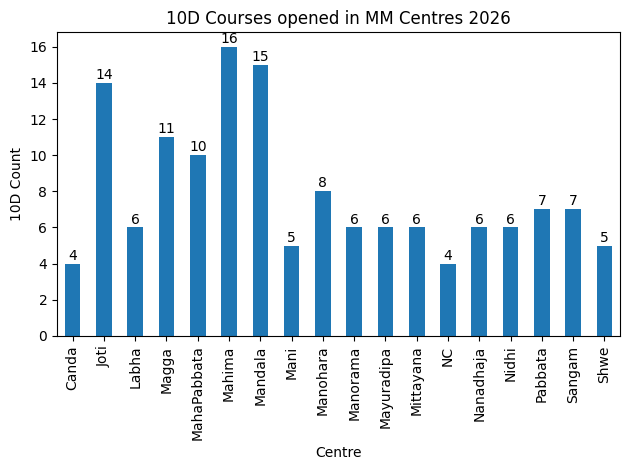

In [ ]:
import matplotlib.pyplot as plt
ax=group10d.plot(kind='bar', title='10D Courses opened in MM Centres 2026')

plt.xlabel('Centre')
plt.ylabel('10D Count')

# add label
for i, v in enumerate(group10d):
    ax.text(i,v + 0.05,str(v),ha= 'center',va='bottom')
plt.tight_layout()
plt.show()

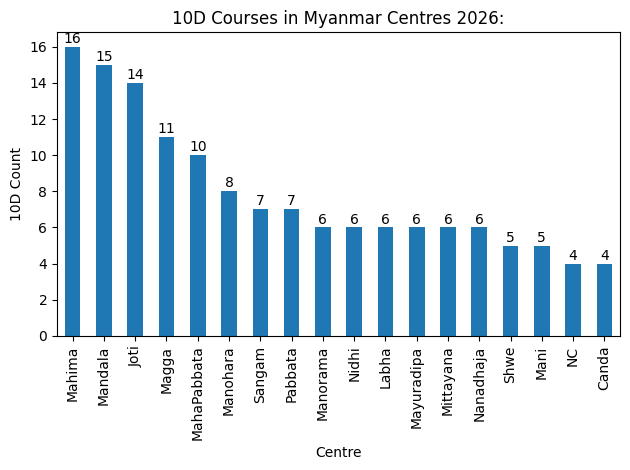

In [ ]:
# bar plot in descending order
import matplotlib.pyplot as plt

grouped=group10d.sort_values(ascending=False)

ax=grouped.plot(kind='bar', title='10D Courses in Myanmar Centres 2026:')

plt.xlabel('Centre')
plt.ylabel('10D Count')

# add label
for i, v in enumerate(grouped):
    ax.text(i,v + 0.05,str(v),ha= 'center',va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
# STP

filteredSTP=data[data['Course']=='STP']
groupSTP=filteredSTP.groupby('Centre')['Course'].count()
print('STP Course Count by Centre:')
groupedSTP=groupSTP.sort_values(ascending=False)
groupedSTP

STP Course Count by Centre:


Centre
Joti           2
Mahima         2
Nidhi          2
MahaPabbata    1
Mandala        1
Mani           1
Manohara       1
Manorama       1
Mayuradipa     1
Mittayana      1
Nanadhaja      1
Pabbata        1
Sangam         1
Shwe           1
Name: Course, dtype: int64

In [ ]:
# 20D 

filteredLC=data[data['Course']=='20D']

filteredLC[['Centre','Course','DateStart','Conduct']].sort_values(by='DateStart', ascending= True)


,Centre,Course,DateStart,Conduct
177,Nidhi,20D,2026-05-05,U Aung Kyaw Nyan Wai Daw K Thi
133,Mahima,20D,2026-09-08,U Maung Maung Lwin Daw Mi Mi Myaing
183,Nidhi,20D,2026-10-08,U Win Myint 1 Daw Mya San


In [ ]:
filteredS10D=data[data['Course']=='S10D']

filteredS10D[['Centre','Course','DateStart','Conduct']]

,Centre,Course,DateStart,Conduct
110,Mandala,S10D,2026-11-13,U Khin Maung Soe Daw Lay Sint
128,Mahima,S10D,2026-07-10,U San Win Daw Tin Tin Ye
179,Nidhi,S10D,2026-07-01,U San Lwin Daw Tin Tin Naing


In [ ]:
# Long Course Centres

df = pd.DataFrame(data)

required_courses = {'20D', '30D', 'S10D'}

# Group by Centre and check if all required courses are present
filtered_centres = df.groupby('Centre')['Course'].apply(lambda x: required_courses.issubset(set(x)))

# Get the Centres that meet the condition
valid_centres = filtered_centres[filtered_centres].index

# Filter the original DataFrame to include only the valid Centres
filtered_data = df[df['Centre'].isin(valid_centres)]

# Get the unique Centres that meet the condition
unique_centres = filtered_centres[filtered_centres].index.tolist()

print('The Centres which operating Long Courses in 2026:')
print(unique_centres)


The Centres which operating Long Courses in 2026:
['Mahima', 'Nidhi']


In [ ]:
# Joti in Dec 2026
print('Courses in Dec of Joti')
JotiDec = df[(df['Month'] == 12) & (df['Centre'] == 'Joti')][['Month','Course','DateStart','DateEnd']]
JotiDec

Courses in Dec of Joti


,Month,Course,DateStart,DateEnd
217,12,1Dsc,2026-12-05,2026-12-05
218,12,10D,2026-12-10,2026-12-21
219,12,3D,2026-12-24,2026-12-27


In [ ]:
# KTKT in Sep
print('Sep Courses for KTKT')
filtered_df = df[(df['Month'] == 9) & (df['Conduct'].str.contains('U Kyaw Thu '))][['Month','Course','Centre','DateStart','DateEnd','Conduct']]
filtered_df 

Sep Courses for KTKT


,Month,Course,Centre,DateStart,DateEnd,Conduct
56,9,STP,Mittayana,2026-09-21,2026-09-29,U Kyaw Thu Daw Kyi Kyi Tun


In [ ]:
import duckdb


df = pd.DataFrame(df)
# Create a DuckDB connection (in-memory database for this example)
con = duckdb.connect()


# Execute the query
result = con.execute("""
    SELECT Month,Course, Centre, Conduct
    FROM df
    WHERE Conduct LIKE '%U Kyaw Thu%'
    ORDER BY DateStart ASC;
""").fetchall()
print('KTKKT Courses in month of 2026')
result

KTKKT Courses in month of 2026


[(4, '10D', 'Sangam', 'U Kyaw Thu Daw Kyi Kyi Tun'),
 (4, 'STP', 'Sangam', 'U Kyaw Thu Daw Kyi Kyi Tun'),
 (7, '10D', 'Joti', 'U Kyaw Thu Daw Kyi Kyi Tun'),
 (8, '10D', 'Manorama', 'U Kyaw Thu Daw Kyi Kyi Tun'),
 (9, 'STP', 'Mittayana', 'U Kyaw Thu Daw Kyi Kyi Tun')]

In [ ]:
# List of my courses in Centres

ktktc= df[(df['Conduct'].str.contains('U Kyaw Thu'))]


print('The Centres to fulfill Paramies in 2026:')
print(ktktc.Centre.unique())

The Centres to fulfill Paramies in 2026:
['Sangam' 'Mittayana' 'Manorama' 'Joti']
